<img src="./logo_UTN.svg" align="right" width="150" /> 

#### Teoría de los Circuitos 2

# Trabajo semanal 1
#### Leandro Robledo



## Introducción
En este Notebook se trabajara sobre el analisis de un filtro activo propuesto por el profesor a modo de comenzar a familiarizarnos con el nuevo entorno de trabajo y la utilizacion de diferentes plataformas como puede ser el LTspcie, Spyder y Jupyter.   


## Actividad
Dadas las siguientes topologías circuitales de un filtro Pasa Banda Pasivo: 
![filtros](Filtros_img.PNG)

Se propone reemplazar el Inductor del filtro de la Fig. 1 con un GIC:
![Girador](Gic_img.PNG)
1. Analizar la [impedancia de entrada desde el nodo Vx](#Zin). Hallar los valores de R4,R5,Y1,Y2 e Y3 de tal manera que responda como un Inductor de valor unitario. 

2. Obtener la [función transferencia $V1/V2$](#V1/V2) Desnormalice convenientemente en[ frecuencia e impedancia para garantizar una $f_0= 10KHz$ y $Q= 20$](#desnorm) utilizando Capacitores entre 1 nF y 100 nF. Para los resistores no hay restricciones. 

3.  Simule la transferencia desnormalizada en Python. Se sugiere programar [la transferencia normalizada](#norm) y definir las normas de frecuencia e impedancia para desnormalizar. Verificar los requerimientos pedidos en 2).
###Bonus  
+1 💎 Obtener los [valores de R4 y R5 para obtener un Pasa Banda con +20 dB](#20db) de ganancia en $f_0$.<br>
+1 💎 Observe la posibilidad ( no se pide realizar ninguna cuenta ) de conectar un GIC en el circuito de la Fig. 2  para reemplazo del Inductor. ¿ [Detecta algún inconveniente o limitación?](#analisis) <br>
+2 💎  Graficar la respuesta de modulo en LTspice con el eje Lineal en frecuencia. Halle numéricamente [$BW=f_2-f_1$ y verifique que $f_0$ es la media geométrica entre $f_1$ y $f_2$](#bw) 
 



### 1)Impedancia de entrada <a id="Zin"></a> <br>
![Z_entrada](Zentrada.jpeg)

### 2) Transferencia <a id="V1/V2"></a> <br>
![Transfer](Transfer.jpeg)
<a id="desnorm"></a> <br>
![Desnormalizacion](Desnorm.jpeg)
<a id="norm"></a> <br>
![Normmalizacion](Normalizacion.jpeg)



In [3]:
# PyTC2: La librería para TC2
from pytc2.sistemas_lineales import pzmap, GroupDelay, bodePlot

from scipy.signal import TransferFunction
import numpy as np
import matplotlib.pyplot as plt
import math


# las librerías que usarremos las cargamos solo una vez.

In [4]:

# Esta parte de código la agregamos SOLO en los notebooks para fijar el estilo de los gráficos.
#
#%%  Inicialización de librerías (esto NO es parte del script demo_seg_orden1.py)
# Setup inline graphics: Esto lo hacemos para que el tamaño de la salida, 
# sea un poco más adecuada al tamaño del jupyter notebook documento

# algún bug cuando lo hice:
plt.figure(1)
plt.close(1)

import matplotlib as mpl

fig_sz_x = 13
fig_sz_y = 7
fig_dpi = 80 # dpi
fig_font_size = 16

mpl.rcParams['figure.figsize'] = (fig_sz_x, fig_sz_y)
mpl.rcParams['figure.dpi'] = fig_dpi
plt.rcParams.update({'font.size':fig_font_size})

#%%  Fin - Inicialización de librerías



(3,
 <Axes: title={'center': 'Retardo de grupo'}, xlabel='Frecuencia angular [rad/seg]', ylabel='Retardo de grupo [seg]'>)

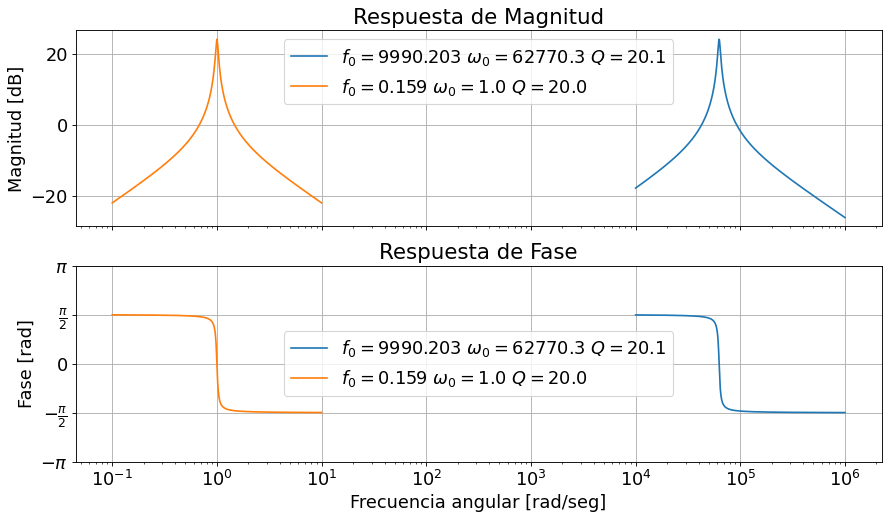

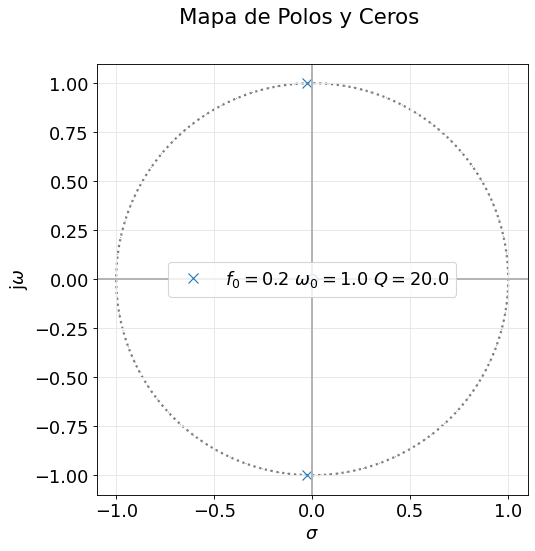

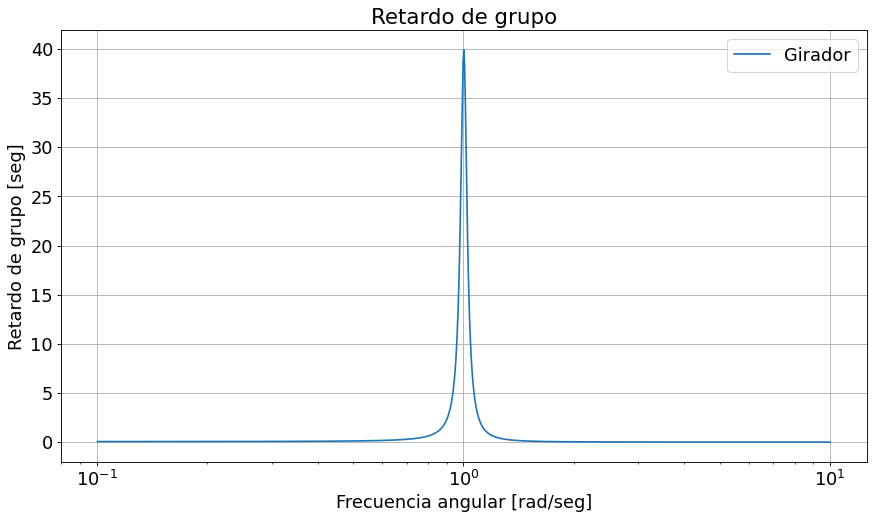

In [6]:
#codigo
#componentes
r=[20,6800]
r4=[15,18000]
r5=[1,1200]
c=[1,47*10**-9]
l=[1,5.4*10**(-3)]


i=[1,0]
for k in i:

    num = [1*(1+r4[k]/r5[k])/(c[k]*r[k]) , 0]   # s /cr *(1+r4/r5)
    den = [1**2 ,1/(c[k]*r[k]) , 1/(c[k]*l[k])]       # s^2 + s/cr + 1/lc
    f0= 1/(2*math.pi*math.sqrt(c[k]*l[k]))
    w0=f0*(2*math.pi)
    Q= (2*math.pi*f0)*r[k]*c[k]
        
    my_tf = TransferFunction(num, den)
    
    bodePlot(my_tf, fig_id=1, filter_description = rf"$f_0={f0:.3f}$ $\omega_0={w0:.1f}$ $Q={Q:.1f}$")
#,xaxis='freq
pzmap(my_tf, fig_id=2, filter_description = rf"$f_0={f0:.1f}$ $\omega_0={w0:.1f}$ $Q={Q:.1f}$")
    
GroupDelay(my_tf, fig_id=3, filter_description = 'Girador')



(4,
 <Axes: title={'center': 'Retardo de grupo'}, xlabel='Frecuencia angular [rad/seg]', ylabel='Retardo de grupo [seg]'>)

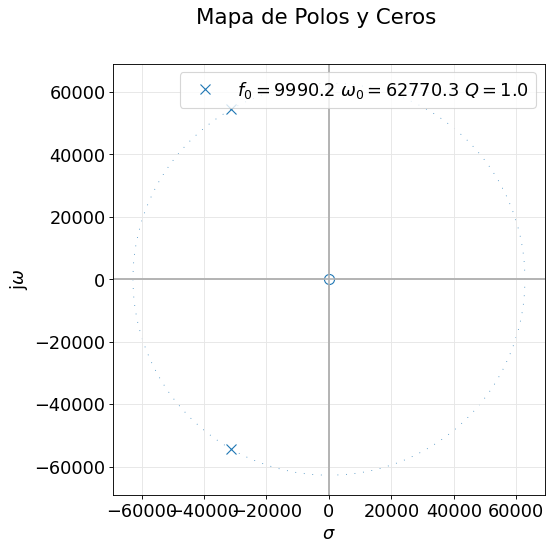

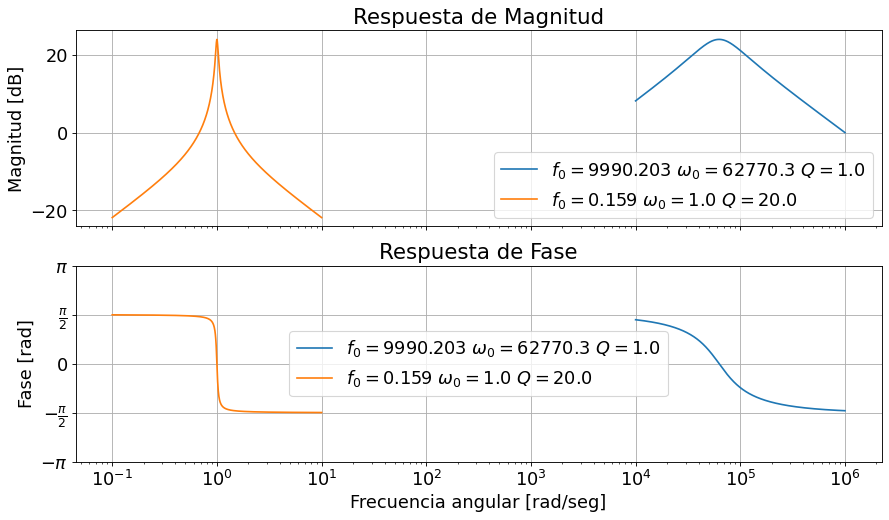

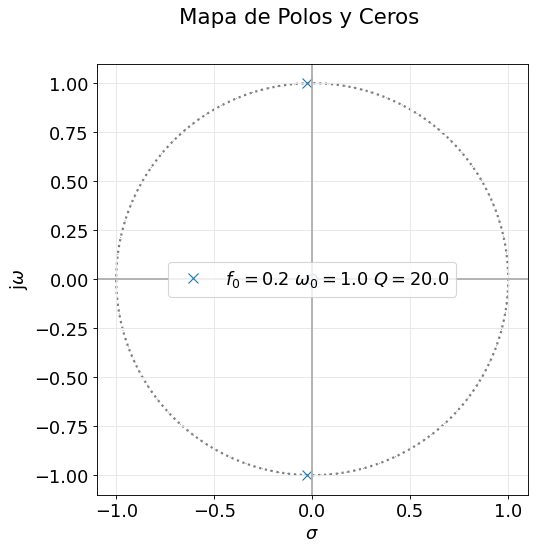

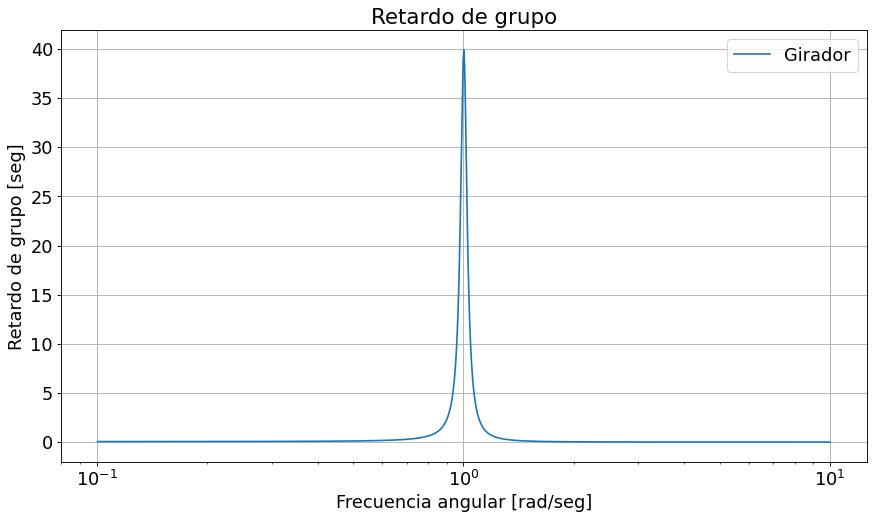

In [78]:
#codigo otro intento con normalizacion
#componentes
#r=[1770,6800]
r4=[15,18000]
r5=[1,1200]

r= 338.95
c= 47*10**-9
l=5.4*10**(-3)
n=[1,62.77*10**3]
z=[1,50*10**-3]

i=[0,1]
for k in i:

    num = [1*(1+r4[k]/r5[k])/(c*n[k]*r/z[k]) , 0]   # s /cr *(1+r4/r5)
    den = [1**2 ,1/(c*n[k]*r/z[k]) , 1/(c*n[k]*l*n[k])]       # s^2 + s/cr + 1/lc
    f0= 1/(2*math.pi*math.sqrt(c*n[k]*l*n[k]))
    w0=f0*(2*math.pi)
    Q= (2*math.pi*f0)*(r/z[k])*c*n[k]
        
    my_tf = TransferFunction(num, den)
    
    bodePlot(my_tf, fig_id=3, filter_description = rf"$f_0={f0:.3f}$ $\omega_0={w0:.1f}$ $Q={Q:.1f}$")
#,xaxis='freq
    pzmap(my_tf, fig_id=k+1, filter_description = rf"$f_0={f0:.1f}$ $\omega_0={w0:.1f}$ $Q={Q:.1f}$")
    
GroupDelay(my_tf, fig_id=4, filter_description = 'Girador')

## BONUS - 
### DESNORMALIZACION CON GANANCIA DE +20db <a id="20db"></a>
Transferencia: 
\begin{equation}
\frac{\frac{S}{CR}(1+\frac{R4}{R5})}{S^2+\frac{S}{CR}+\frac{1}{CL}}
\end{equation}
Por lo que la ganancia esta delimitada por la relacion entre $1+\frac{R4}{R5}$ calculando:

\begin{equation}
20log_{10}(1+\frac{R4}{R5})=20db \Rightarrow R4>9 R5 \Rightarrow R4=15 R5
\end{equation}

![+20DB](+20db.PNG)
### Analisis circuito <a id="analisis"></a>
Este circuito traeria problemas al utilizar la bobina en serie, el girador no estaria "aterrizado" por lo que su funcionamiento podria no ser optimo y deberia de rediseñarse. Otros problemas que se tienen es si utilizamos los valores normalizados de los componentes podriamos poner cosas en corto, como puede ser la salida o despolarizaro los amplificadores si utilizamos resistencias muy bajas. 

### Bandwidth <a id="bw"></a>
Aclaracion, los valores de los componentes fueron modificados para una respuesta mas facil de visualizar.<br>
Como se puede observar en las siguientes imagenes, el pico maximo de la respuesta en frecuencia se encuentra en $f_0=9.85kHz$ con un modulo de $H_(j\omega)=25.64Hz$, por otro lado la definicion del ancho de banda es cuando la respuesta cae 3db, por lo que tenemos: $f_1=8.31KHz$ y $f_2=11.6KHz$. Esto se debe a que el eje de frecuencia esta en escala logaritmica. 
\begin{equation}
f_1-f_2=11.6KHz-8.31KHz=3.29KHz
\end{equation}

\begin{equation}
\frac{f_1-f_2}{2}=1.65KHz=\Delta Bw
\end{equation}

\begin{equation}
f_1+\Delta Bw = f_0 \cong 9.9KHz
\end{equation}
Lo que verifica lo que se ve en las siguientes imagenes:

![Frec_max](Bw_centro.PNG)
![Bw](Bw_media.PNG)
